# 8. 성능 최적화
## 8.3.하이퍼파라미터를 이용한 성능 최적화

### 8.3.2 드롭아웃을 이용한 성능 최적화

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim

In [ ]:
trainset = torchvision.datasets.FashionMNIST(
    root='../chap08/data/',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

In [ ]:
batch_size = 4

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True
)

In [ ]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.shape)
print(images[0].shape)
print(labels[0].item())

torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
3


In [ ]:
# 이미지 데이터 출력하기 위한 전처리
def imshow(img, title):
    plt.figure(figsize=(batch_size * 4, 4)) # 출력할 이미지 크기 지정
    plt.axis('off')
    plt.imshow(np.transpose(img, (1, 2, 0))) # matplotblib 출력하기 위한 형태

    plt.title(title)
    plt.show()

In [ ]:
# 이미지 데이터 출력 함수
def show_batch_images(dataloader):
    images, labels = next(iter(dataloader))

    img = torchvision.utils.make_grid(images)
    imshow(img, title=[str(x.item()) for x in labels])

    return images, labels

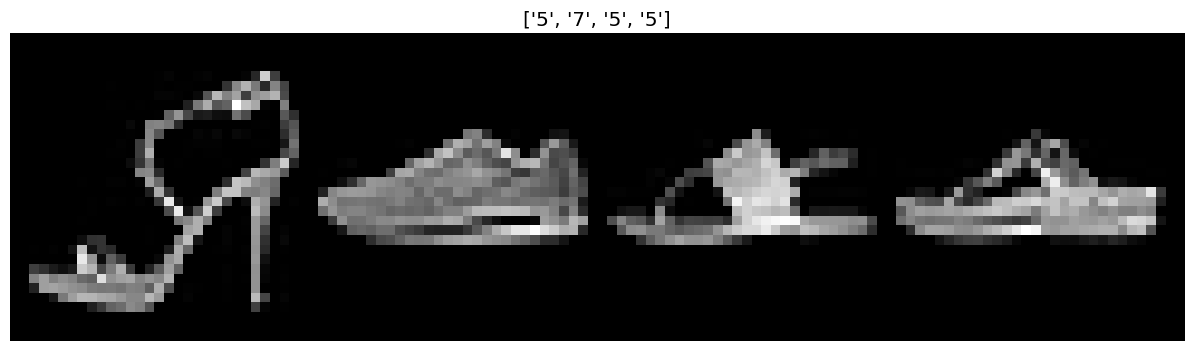

In [ ]:
# 출력
images, labels = show_batch_images(trainloader)

In [ ]:
# 배치 정규화가 적용되지 않은 네트워크 (비교용)
class NormalNet(nn.Module):
    def __init__(self):
        super(NormalNet, self).__init__()

        self.classifier = nn.Sequential(
            nn.Linear(784, 48),
            nn.ReLU(),

            nn.Linear(48, 24),
            nn.ReLU(),

            nn.Linear(24, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.classifier(x)

        return x

In [ ]:
# 배치 정규화가 포함된 네트워크
class BNNet(nn.Module):
    def __init__(self):
        super(BNNet, self).__init__()

        self.classifier = nn.Sequential(
            nn.Linear(784, 48),
            nn.BatchNorm1d(48), # 배치 정규화 적용되는 부분
            nn.ReLU(),

            nn.Linear(48, 24),
            nn.BatchNorm1d(24),
            nn.ReLU(),

            nn.Linear(24, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.classifier(x)

        return x

In [ ]:
# 배치 정규화 x 모델 선언
model = NormalNet()
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [ ]:
# 베치 정규화 o 모델 선언
model_bn = BNNet()
print(model_bn)

BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [ ]:
# 데이터셋 메모리로 로드
batch_size = 512

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True
)

In [ ]:
loss_fn = nn.CrossEntropyLoss()

opt = optim.SGD(model.parameters(), lr=0.01)
opt_bn = optim.SGD(model_bn.parameters(), lr=0.01)

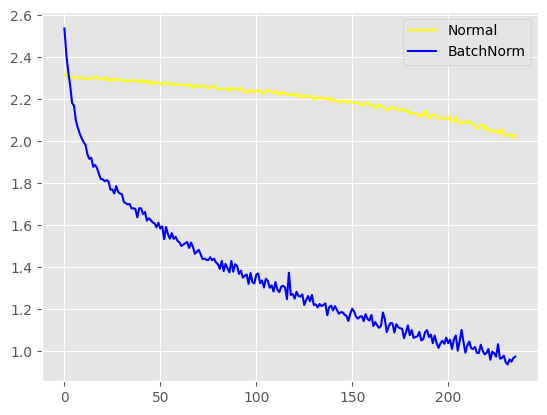

In [ ]:
## 모델 학습
loss_arr = []
loss_bn_arr = []

max_epochs = 2

for epoch in range(max_epochs):
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        # 배치 정규화가 적용되지 않은 모델 학습
        opt.zero_grad()

        outputs = model(inputs)
        loss = loss_fn(outputs, labels)

        loss.backward()
        opt.step()

        # 배치 정규화가 적용된 모델 학습
        opt_bn.zero_grad()

        outputs_bn = model_bn(inputs)
        loss_bn = loss_fn(outputs_bn, labels)

        loss_bn.backward()
        opt_bn.step()

        loss_arr.append(loss.item())
        loss_bn_arr.append(loss_bn.item())

plt.plot(loss_arr, color='yellow', label='Normal')
plt.plot(loss_bn_arr, color='blue', label='BatchNorm')

plt.legend()
plt.show()

둘 다 시간 흐를수록 오차 줄지만 감소 범위와 값에 차이 있음.

In [ ]:
# 데이터셋 분포 출력용 전처리
N = 50
noise = 0.3

x_train = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_train = x_train + noise * torch.normal(
    torch.zeros(N, 1),
    torch.ones(N, 1)
)

x_test = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_test = x_test + noise * torch.normal(
    torch.zeros(N, 1),
    torch.ones(N, 1)
)

In [ ]:
import torch
print(torch.linspace(0,10, 100))
print('----------')
print(torch.linspace(0,10,5))

tensor([ 0.0000,  0.1010,  0.2020,  0.3030,  0.4040,  0.5051,  0.6061,  0.7071,
         0.8081,  0.9091,  1.0101,  1.1111,  1.2121,  1.3131,  1.4141,  1.5152,
         1.6162,  1.7172,  1.8182,  1.9192,  2.0202,  2.1212,  2.2222,  2.3232,
         2.4242,  2.5253,  2.6263,  2.7273,  2.8283,  2.9293,  3.0303,  3.1313,
         3.2323,  3.3333,  3.4343,  3.5354,  3.6364,  3.7374,  3.8384,  3.9394,
         4.0404,  4.1414,  4.2424,  4.3434,  4.4444,  4.5455,  4.6465,  4.7475,
         4.8485,  4.9495,  5.0505,  5.1515,  5.2525,  5.3535,  5.4545,  5.5556,
         5.6566,  5.7576,  5.8586,  5.9596,  6.0606,  6.1616,  6.2626,  6.3636,
         6.4646,  6.5657,  6.6667,  6.7677,  6.8687,  6.9697,  7.0707,  7.1717,
         7.2727,  7.3737,  7.4747,  7.5758,  7.6768,  7.7778,  7.8788,  7.9798,
         8.0808,  8.1818,  8.2828,  8.3838,  8.4848,  8.5859,  8.6869,  8.7879,
         8.8889,  8.9899,  9.0909,  9.1919,  9.2929,  9.3939,  9.4949,  9.5960,
         9.6970,  9.7980,  9.8990, 10.00

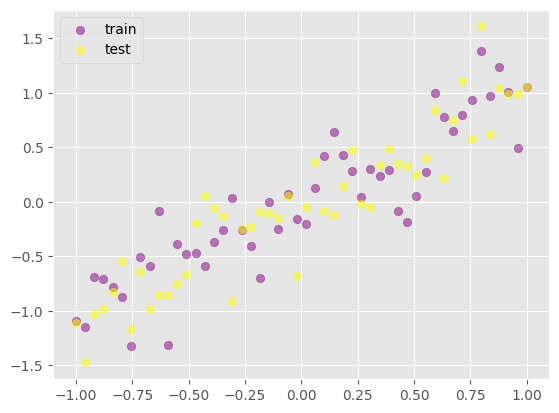

In [ ]:
# 앞에서 전처리된 데이터를 그래프로 출력해 분포 확인
plt.scatter(
    x_train.data.numpy(),
    y_train.data.numpy(),
    c='purple',
    alpha=0.5,
    label='train'
)

plt.scatter(
    x_test.data.numpy(),
    y_test.data.numpy(),
    c='yellow',
    alpha=0.5,
    label='test'
)

plt.legend()
plt.show()

In [ ]:
# 드롭아웃을 위한 모델 생성

N_h = 100

# 드롭아웃이 적용되지 않은 모델
model = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.ReLU(),

    torch.nn.Linear(N_h, N_h),
    torch.nn.ReLU(),

    torch.nn.Linear(N_h, 1)
)

# 드롭아웃이 적용된 모델
model_dropout = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),

    torch.nn.Linear(N_h, N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),

    torch.nn.Linear(N_h, 1)
)

In [ ]:
opt = torch.optim.Adam(model.parameters(), lr=0.01)
opt_dropout = torch.optim.Adam(model_dropout.parameters(), lr=0.01)

loss_fn = torch.nn.MSELoss()

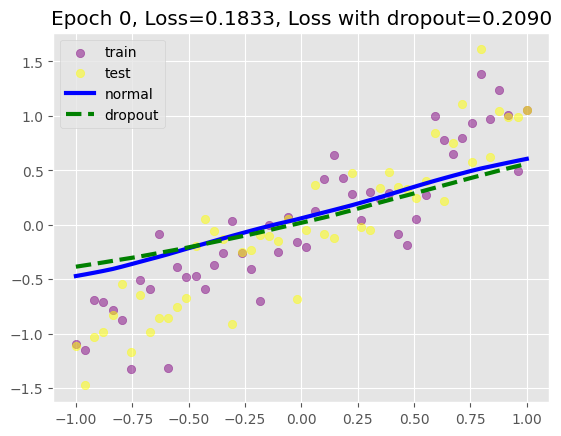

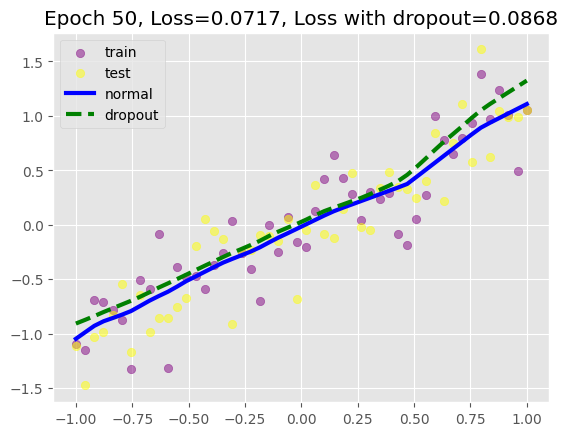

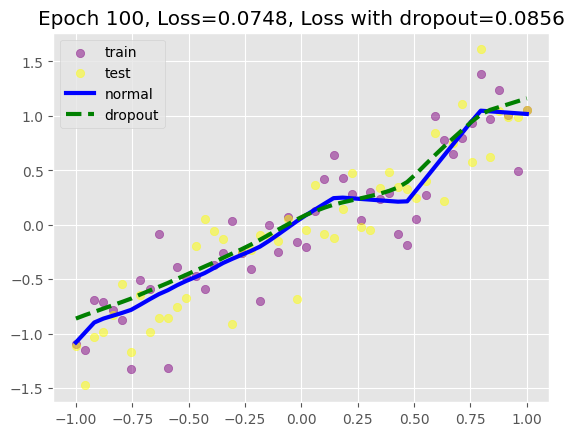

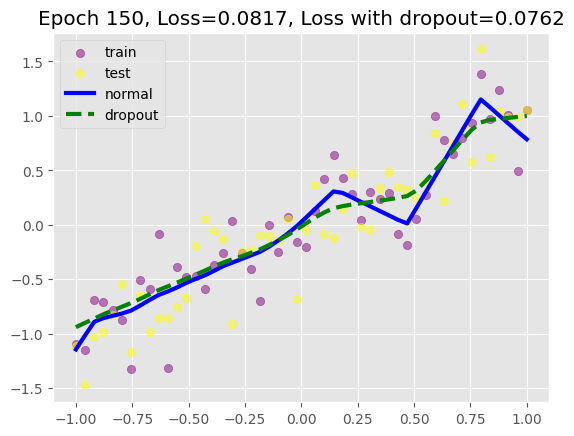

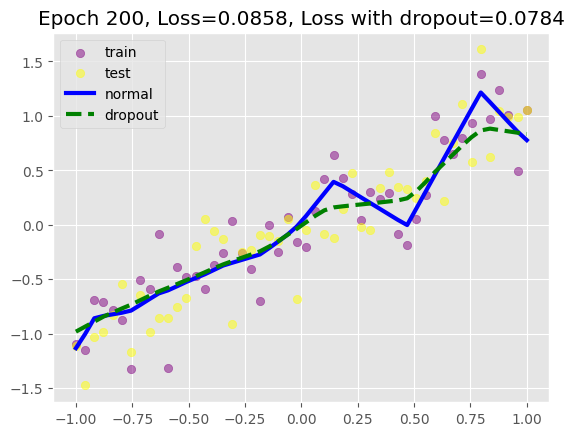

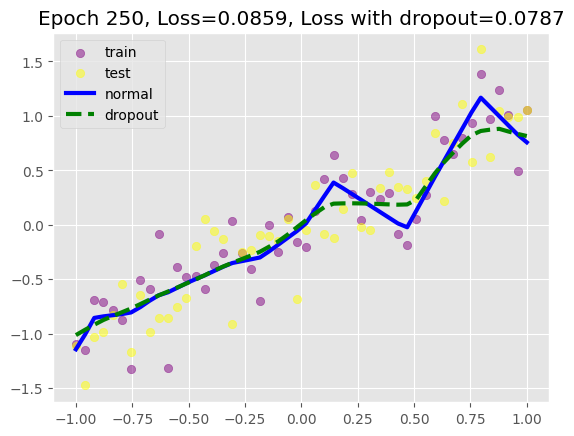

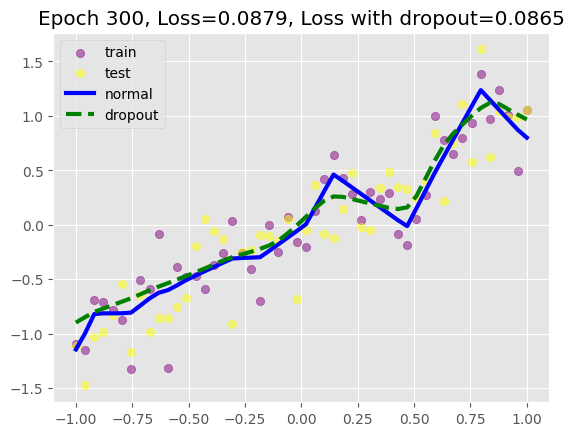

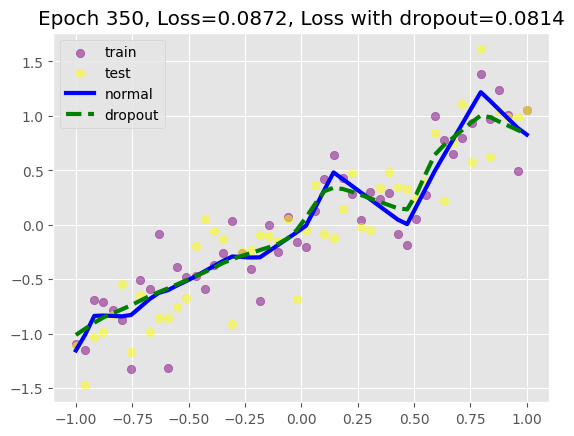

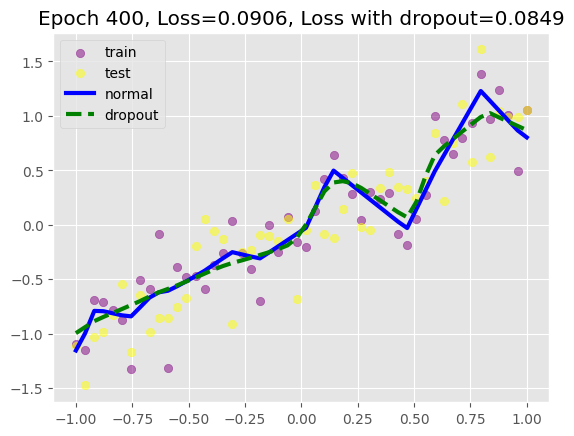

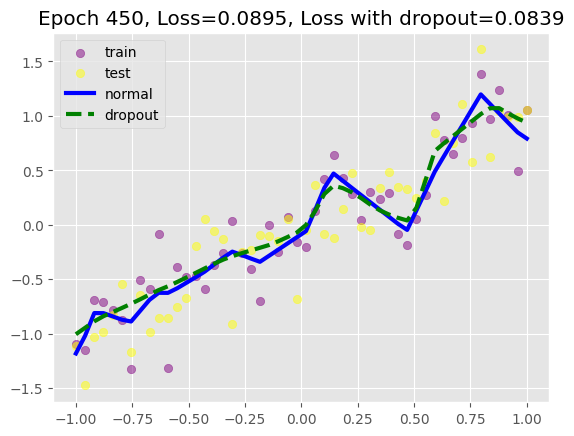

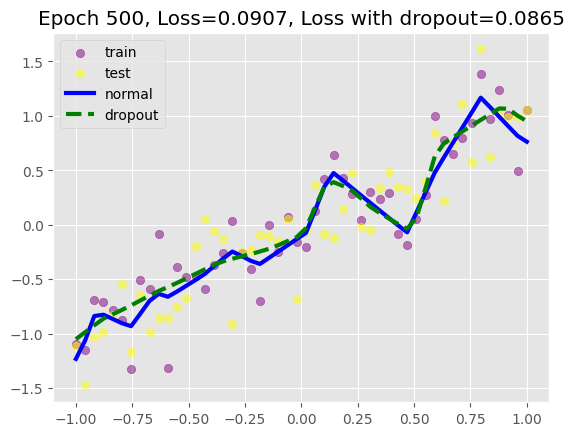

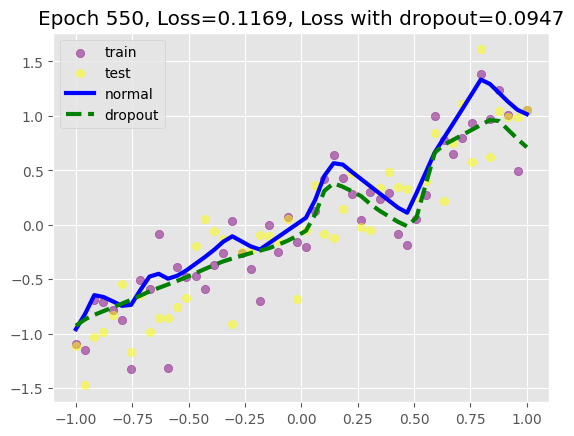

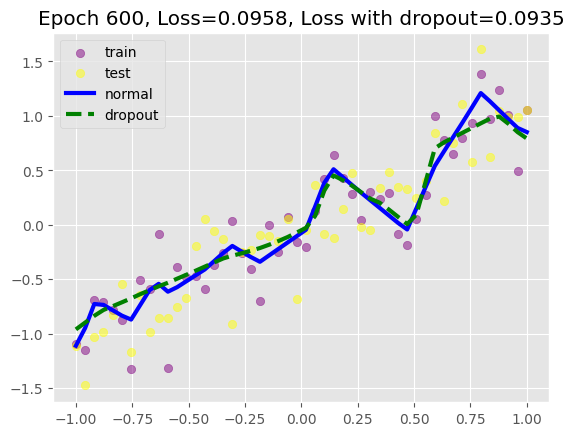

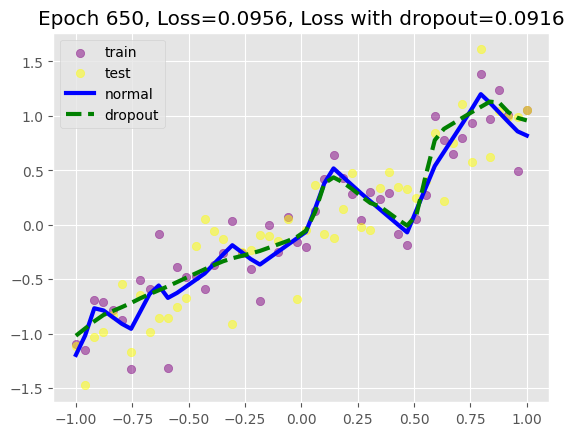

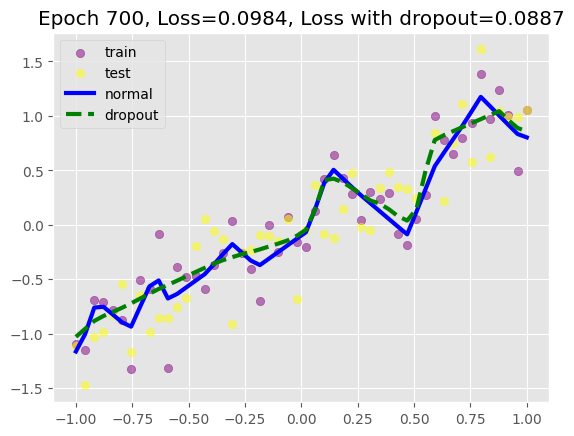

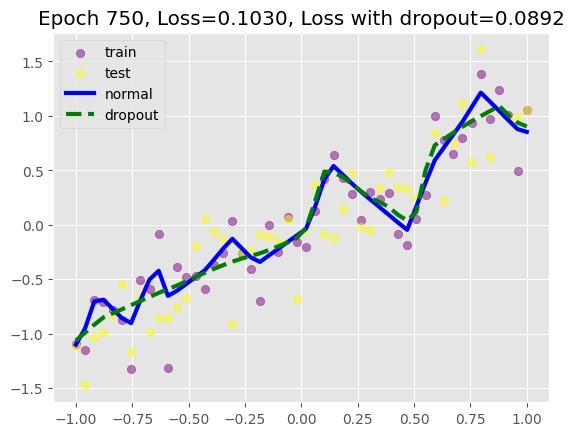

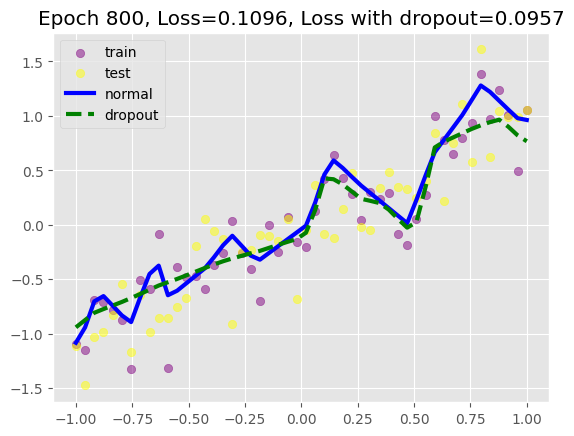

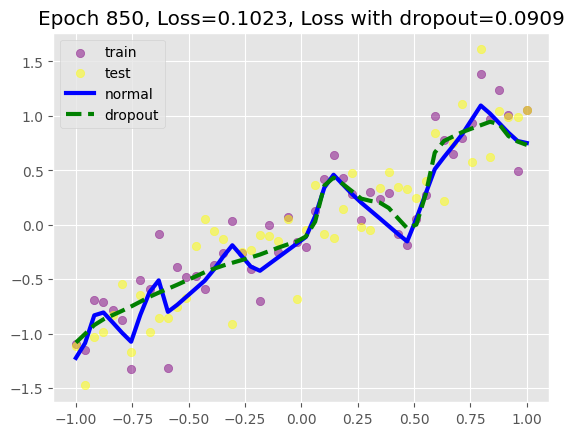

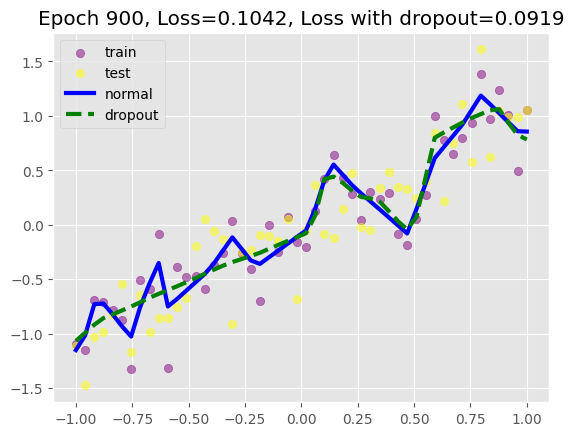

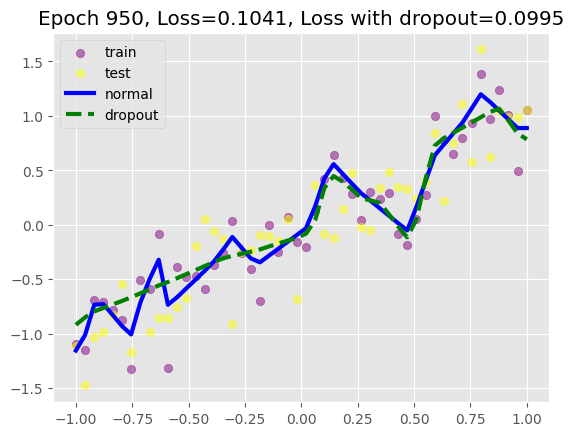

In [ ]:
# 드롭아웃 o, x 모델 각각 학습시키고 오차 출력

max_epochs = 1000
for epoch in range(max_epochs):
    # 드롭아웃이 적용되지 않은 모델 학습
    pred = model(x_train)
    loss = loss_fn(pred, y_train)

    opt.zero_grad()
    loss.backward()
    opt.step()

    # 드롭아웃이 적용된 모델 학습
    pred_dropout = model_dropout(x_train)
    loss_dropout = loss_fn(pred_dropout, y_train)

    opt_dropout.zero_grad()
    loss_dropout.backward()
    opt_dropout.step()

    # 에포크를 50으로 나눠서 나머지 0이면 다음 진행
    if epoch % 50 == 0:
        model.eval()
        model_dropout.eval()

        test_pred = model(x_test)
        test_loss = loss_fn(test_pred, y_test)

        test_pred_dropout = model_dropout(x_test)
        test_loss_dropout = loss_fn(test_pred_dropout, y_test)

        plt.scatter(
            x_train.data.numpy(),
            y_train.data.numpy(),
            c='purple',
            alpha=0.5,
            label='train'
        )

        plt.scatter(
            x_test.data.numpy(),
            y_test.data.numpy(),
            c='yellow',
            alpha=0.5,
            label='test'
        )

        plt.plot(
            x_test.data.numpy(),
            test_pred.data.numpy(),
            'b-',
            lw=3,
            label='normal'
        )

        plt.plot(
            x_test.data.numpy(),
            test_pred_dropout.data.numpy(),
            'g--',
            lw=3,
            label='dropout'
        )

        plt.title(
            'Epoch %d, Loss=%0.4f, Loss with dropout=%0.4f'
            % (epoch, test_loss, test_loss_dropout)
        )

        plt.legend()

        model.train()
        model_dropout.train()

        plt.pause(0.05)

전반적으로 오차가 줄어드는 범위는 크지 않으나 드롭아웃을 적용했을 때의 오차가 더 낮다.

훈련 횟수가 늘어날수록 파란색 실선은 자주색 점들을 찾아가고 있는데 이는 자주색 선(훈련 데이터셋) 과적합 현상을 보인다는 의미

### 8.3.3 조기 종료를 이용한 성능 최적화

In [ ]:
args['lr_scheduler'] = True
args['early_stopping'] = True

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms, datasets

import matplotlib
import matplotlib.pyplot as plt
import time
import argparse
import numpy as np

from tqdm import tqdm

matplotlib.style.use('ggplot')

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [ ]:
# 데이터셋 전처리
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
!git clone --depth 1 https://github.com/gilbutITbook/080289.git

fatal: destination path '080289' already exists and is not an empty directory.


In [ ]:
data_root = '/content/080289/chap08/data/archive'

train_dataset = datasets.ImageFolder(
    root=f'{data_root}/train',
    transform=train_transform
)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_dataset = datasets.ImageFolder(
    root=f'{data_root}/test',
    transform=val_transform
)

val_dataloader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [1]:
# 모델 생성

def resnet50(pretrained=True, requires_grad=False):
    model = models.resnet50(
        progress=True,
        pretrained=pretrained
    )

    if requires_grad == False:
        for param in model.parameters():
            param.requires_grad = False

    elif requires_grad == True:
        for param in model.parameters():
            param.requires_grad = True

    model.fc = nn.Linear(2048, 2)

    return model

In [ ]:
# 학습률 감소: 주어진 patient 횟수만큼 검증 데이터셋에 대한 오차 감소 없으면 factor만큼 lr 감소
class LRScheduler():
    def __init__(
        self,
        optimizer,
        patience=5,
        min_lr=1e-6,
        factor=0.5
    ):
        self.optimizer = optimizer
        self.patience = patience
        self.min_lr = min_lr
        self.factor = factor

        self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='min',
            patience=self.patience,
            factor=self.factor,
            min_lr=self.min_lr
        )

    def __call__(self, val_loss):
        self.lr_scheduler.step(val_loss)

In [ ]:
# 조기종료
class EarlyStopping():
    def __init__(
        self,
        patience=5,
        verbose=False,
        delta=0,
        path='../chap08/data/checkpoint.pt'
    ):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)

        elif score < self.best_score + self.delta:
            self.counter += 1

            print(
                f'EarlyStopping counter: '
                f'{self.counter} out of {self.patience}'
            )

            if self.counter >= self.patience:
                self.early_stop = True

        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(
                f'Validation loss decreased '
                f'({self.val_loss_min:.6f} --> {val_loss:.6f}). '
                f'Saving model ...'
            )

        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

1. patience: 오차 개선이 없다고 바로 종료하지 않음. 개선이 없는 에포크를 얼마나 기다려 줄지 지정
2. delta: 오차가 개선되고 있다고 판단하기 위한 최소 변화량.

In [ ]:
# 인수 값 지정
parser = argparse.ArgumentParser()

parser.add_argument(
    '--lr-scheduler', # 옵션 문자열의 이름으로 명령을 실행할 때 사용
    dest='lr_scheduler', #입력 값이 저장되는 변수
    action='store_true' #action을 store_true로 지정하면 입력 값을 dest 파라미터에 의해 생성된 변수에 저장
) #원하는 인수 값 추가

parser.add_argument(
    '--early-stopping',
    dest='early_stopping',
    action='store_true'
)

args, unknown = parser.parse_known_args()
args = vars(args)

In [ ]:
print(f'Computation device: {device}\n')
model = models.resnet50(pretrained=True).to(device)

total_params = sum(
    p.numel() for p in model.parameters()
)

print(f'{total_params:,} total parameters.')

total_trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f'{total_trainable_params:,} training parameters.')

Computation device: cuda:0



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


25,557,032 total parameters.
25,557,032 training parameters.


In [ ]:
lr = 0.001
epochs = 100

optimizer = optim.Adam(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

In [ ]:
# 오차, 정확도, 모델명에 대한 문자열
loss_plot_name = 'loss'
acc_plot_name = 'accuracy'
model_name = 'model'

In [ ]:
if args['lr_scheduler']:
    print('INFO: Initializing learning rate scheduler')

    lr_scheduler = LRScheduler(optimizer)

    loss_plot_name = 'lrs_loss'
    acc_plot_name = 'lrs_accuracy'
    model_name = 'lrs_model'

if args['early_stopping']:
    print('INFO: Initializing early stopping')

    early_stopping = EarlyStopping()

    loss_plot_name = 'es_loss'
    acc_plot_name = 'es_accuracy'
    model_name = 'es_model'

In [ ]:
# 모델 학습
def training(
    model,
    train_dataloader,
    train_dataset,
    optimizer,
    criterion
):
    print('Training')

    model.train()

    train_running_loss = 0.0
    train_running_correct = 0

    counter = 0
    total = 0

    prog_bar = tqdm(
        enumerate(train_dataloader),
        total=int(len(train_dataset) / train_dataloader.batch_size)
    )

    for i, data_batch in prog_bar:
        counter += 1

        images, target = data_batch
        images = images.to(device)
        target = target.to(device)

        total += target.size(0)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, target)

        train_running_loss += loss.item()

        _, preds = torch.max(outputs.data, 1)

        train_running_correct += (
            preds == target
        ).sum().item()

        loss.backward()
        optimizer.step()

    train_loss = train_running_loss / counter
    train_accuracy = 100.0 * train_running_correct / total

    return train_loss, train_accuracy

In [ ]:
# 모델 검증 함수
def validate(model, test_dataloader, val_dataset, criterion):
    print('Validating')

    model.eval()

    val_running_loss = 0.0
    val_running_correct = 0

    counter = 0
    total = 0

    prog_bar = tqdm(
        enumerate(test_dataloader),
        total=int(len(val_dataset) / test_dataloader.batch_size)
    )

    with torch.no_grad():
        for i, data_batch in prog_bar:
            counter += 1

            images, target = data_batch
            images = images.to(device)
            target = target.to(device)

            total += target.size(0)

            outputs = model(images)
            loss = criterion(outputs, target)

            val_running_loss += loss.item()

            _, preds = torch.max(outputs.data, 1)

            val_running_correct += (
                preds == target
            ).sum().item()

    val_loss = val_running_loss / counter
    val_accuracy = 100.0 * val_running_correct / total

    return val_loss, val_accuracy

In [ ]:
# 모델 학습
train_loss, train_accuracy = [], []
val_loss, val_accuracy = [], []

start = time.time()

for epoch in range(epochs):
    print(f'Epoch {epoch + 1} of {epochs}')

    train_epoch_loss, train_epoch_accuracy = training(
        model,
        train_dataloader,
        train_dataset,
        optimizer,
        criterion
    )

    val_epoch_loss, val_epoch_accuracy = validate(
        model,
        val_dataloader,
        val_dataset,
        criterion
    )

    train_loss.append(train_epoch_loss)
    train_accuracy.append(train_epoch_accuracy)

    val_loss.append(val_epoch_loss)
    val_accuracy.append(val_epoch_accuracy)

    # 학습률 감소 적용
    if args['lr_scheduler']:
        lr_scheduler(val_epoch_loss)

    # 조기 종료 적용
    if args['early_stopping']:
        early_stopping(val_epoch_loss, model)

        if early_stopping.early_stop:
            print('Early stopping activated.')
            break

    print(
        f'Train Loss: {train_epoch_loss:.4f}, '
        f'Train Acc: {train_epoch_accuracy:.2f}'
    )

    print(
        f'Val Loss: {val_epoch_loss:.4f}, '
        f'Val Acc: {val_epoch_accuracy:.2f}'
    )

end = time.time()

print(f'Training time: {(end - start) / 60:.3f} minutes')

Epoch 1 of 100
Training


16it [00:06,  2.37it/s]


Validating


16it [00:04,  3.31it/s]


Train Loss: 0.6190, Train Acc: 64.66
Val Loss: 0.4350, Val Acc: 83.60
Epoch 2 of 100
Training


...

Train Loss: 0.1217, Train Acc: 95.18
Val Loss: 0.3165, Val Acc: 88.40
Epoch 100 of 100
Training


16it [00:04,  3.76it/s]


Validating


16it [00:03,  4.47it/s]

Train Loss: 0.1168, Train Acc: 94.78
Val Loss: 0.3260, Val Acc: 89.20
Training time: 12.879 minutes


Saving loss and accuracy plots...


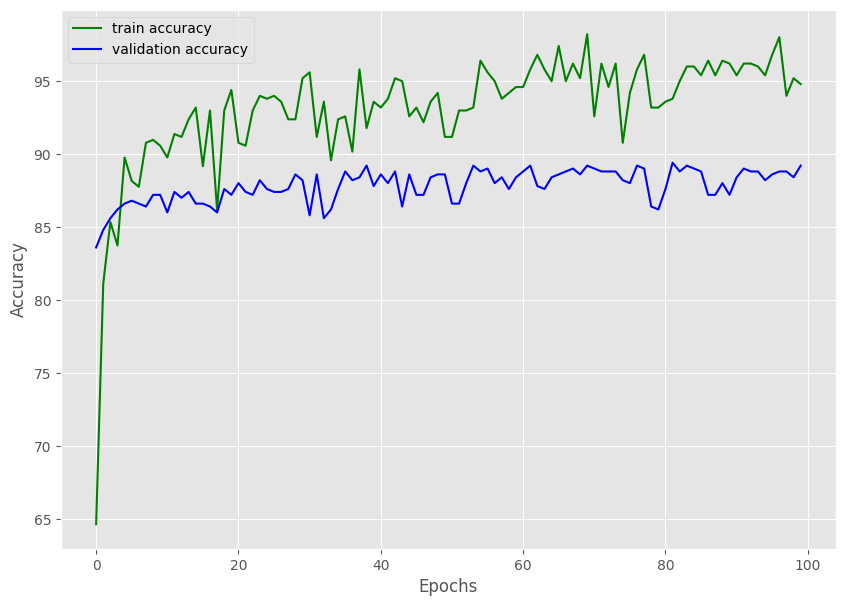

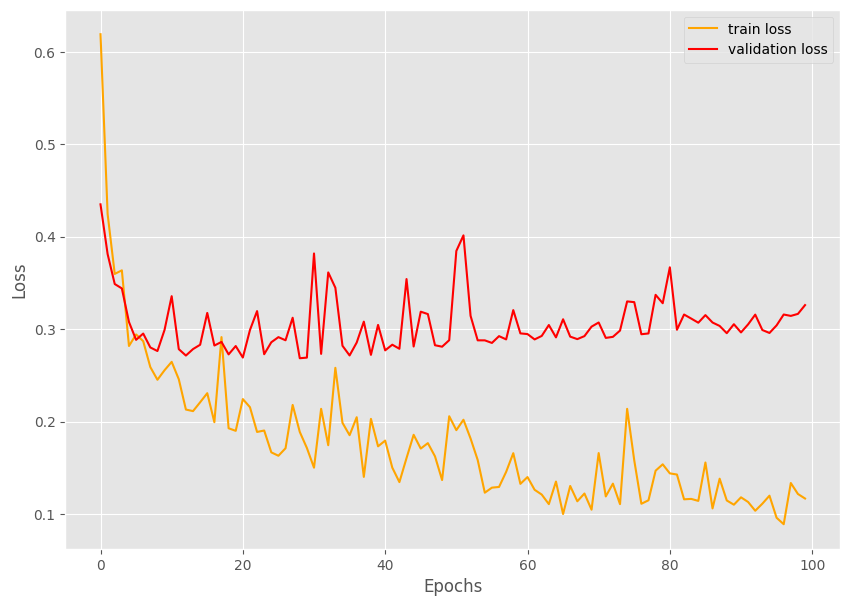

Saving model...
TRAINING COMPLETE


In [ ]:
# 모델 학습 결과 출력
print('Saving loss and accuracy plots...')


plt.figure(figsize=(10, 7))

# 훈련 데이터셋에 대한 정확도 그래프로 출력
plt.plot(
    train_accuracy,
    color='green',
    label='train accuracy'
)

# 검증 데이터셋에 대한 정확도 그래프로 출력
plt.plot(
    val_accuracy,
    color='blue',
    label='validation accuracy'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig(f'../chap08/img/{acc_plot_name}.png')
plt.show()


# 손실 그래프
plt.figure(figsize=(10, 7))

plt.plot(
    train_loss,
    color='orange',
    label='train loss'
)

plt.plot(
    val_loss,
    color='red',
    label='validation loss'
)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.savefig(f'../chap08/img/{loss_plot_name}.png')
plt.show()


# 모델 저장
print('Saving model...')

torch.save(
    model.state_dict(),
    f'../chap08/img/{model_name}.pth'
)

print('TRAINING COMPLETE')

[결과] <br>
다섯 번째 에포크부터 조기 종료가 수행되고 있기 때문에 실제로 학습은 네 번째 에포크까지만 수행되었다고 할 수 있다. <br>
조기 종료 > 항상 성능에 좋은 영향? NO. <br>
조기 종료로 인해 모델이 학습을 제대로 하지 못할 수도 있다.